# MLP Classification Analysis for All Datasets

This notebook applies Multi-Layer Perceptron (MLP) classification with nested cross-validation to all three datasets:
1. **Telco Customer Churn** - Predicting customer churn
2. **Online Shoppers Intention** - Predicting purchase intention
3. **Bank Marketing** - Predicting term deposit subscription

## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    TimeSeriesSplit,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

print('Libraries imported successfully!')

Libraries imported successfully!


## Shared helper: encode features

The cleaned CSVs still contain string and boolean categorical columns that must be
one-hot encoded before entering the pipeline. All numeric values are already clean
and free of nulls. Unlike KNN/chi2, MLP handles negative values natively so no
`clip(lower=0)` is needed — `StandardScaler` will centre and scale everything.

In [2]:
def encode_features(X):
    """One-hot encode remaining categorical/bool columns."""
    cat_cols = X.select_dtypes(include=['object', 'str', 'bool']).columns.tolist()
    if cat_cols:
        X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=float)
    return X.astype(float)

In [3]:
def sort_bank_temporally(df):
    """Sort Bank Marketing rows chronologically by month and day_of_week.

    Mirrors src/evaluation.py's sort_dataframe_temporally so that the Bank
    train/test split below is comparable to the temporal split used for
    Gradient Boosting and the Random Forest deep-dive analysis (paper
    Section 3.4 mandates a temporal split for Bank to avoid look-ahead bias).
    """
    month_order = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
                   'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
    day_order = {'mon':1,'tue':2,'wed':3,'thu':4,'fri':5}
    month_num = df['month'].str.lower().map(month_order)
    day_num = df['day_of_week'].str.lower().map(day_order)
    time_idx = month_num * 100 + day_num
    return df.assign(_time_idx=time_idx).sort_values('_time_idx').drop(columns=['_time_idx']).reset_index(drop=True)

## Shared helper: run nested CV + final evaluation

Nested CV structure:
- **Outer loop** (`StratifiedKFold`, 5 folds): estimates generalisation performance without bias.
- **Inner loop** (`GridSearchCV` + `StratifiedKFold`, 5 folds): selects best `hidden_layer_sizes` and `alpha` using `roc_auc`.

After nested CV, the pipeline is refit on the full training set (70%) with the best
hyperparameters, then evaluated on the held-out test set (30%).

In [4]:
def run_mlp_pipeline(X, y, dataset_name, class_labels, temporal=False):

    print(f"\n{'='*60}")
    print(f'  {dataset_name}')
    print(f"{'='*60}")
    print(f'Class distribution:\n{pd.Series(y).value_counts()}')

    # ------------------------------------------------------------------
    # 1. Train / test split  (NO preprocessing happens here)
    # ------------------------------------------------------------------
    if temporal:
        split_idx = int(len(X) * 0.8)
        X_train, X_test = X[:split_idx], X[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]
        print(f'\nTemporal split at index {split_idx} (no shuffling).')
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.30, stratify=y, random_state=42
        )
    print(f'\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

    # ------------------------------------------------------------------
    # 2. Pipeline: StandardScaler -> MLP
    #
    #    StandardScaler is fit only on each training fold inside CV.
    #    max_iter=500 avoids convergence warnings on larger datasets;
    #    early_stopping=True halts training when validation loss stops
    #    improving, acting as an additional regulariser.
    # ------------------------------------------------------------------
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp',    MLPClassifier(
            max_iter=500,
            early_stopping=True,
            random_state=42,
        )),
    ])

    param_grid = {
        'mlp__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
        'mlp__alpha':              [0.0001, 0.001, 0.01],
    }

    # ------------------------------------------------------------------
    # 3. Nested cross-validation
    # ------------------------------------------------------------------
    outer_cv = TimeSeriesSplit(n_splits=5) if temporal else StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    inner_search = GridSearchCV(
        pipe,
        param_grid,
        cv=inner_cv,
        scoring='roc_auc',
        n_jobs=-1,
    )

    nested_scores = cross_val_score(
        inner_search,
        X_train, y_train,
        cv=outer_cv,
        scoring='roc_auc',
        n_jobs=-1,
    )

    print(f'\nNested CV ROC-AUC scores: {np.round(nested_scores, 4)}')
    print(f'Mean: {nested_scores.mean():.4f}  (+/- {nested_scores.std():.4f})')

    # ------------------------------------------------------------------
    # 4. Final model: refit on full training set with best hyperparameters
    # ------------------------------------------------------------------
    inner_search.fit(X_train, y_train)
    best_params = inner_search.best_params_
    print(f'\nBest hyperparameters selected by inner CV:')
    for k, v in best_params.items():
        print(f'  {k}: {v}')

    # ------------------------------------------------------------------
    # 5. Evaluation on held-out test set
    # ------------------------------------------------------------------
    y_pred  = inner_search.predict(X_test)
    y_proba = inner_search.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, y_proba)
    test_f1 = f1_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    print(f'\nTest set ROC-AUC: {test_auc:.4f}')
    print(f'\nClassification report (test set):')
    print(classification_report(y_test, y_pred, target_names=class_labels))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels).plot(
        cmap='BuPu', colorbar=False
    )
    plt.title(f'{dataset_name} — Confusion Matrix (test set)')
    plt.tight_layout()
    plt.show()

    n_features = X_train.shape[1]

    train_acc = accuracy_score(y_train, inner_search.predict(X_train))
    valid_acc = accuracy_score(y_test, y_pred)

    return {
        'dataset':              dataset_name,
        'features':             n_features,
        'best_params':          best_params,
        'train_accuracy':       train_acc,
        'valid_accuracy':       valid_acc,
        'mean_cv_score':        nested_scores.mean(),
        'cv_score_std':         nested_scores.std(),
        'test_auc':             test_auc,
        'test_f1':              test_f1,
        'test_precision':       test_precision,
        'test_recall':          test_recall,
    }

---
## 1. Telco Customer Churn Dataset

In [5]:
df_telco = pd.read_csv('../data/processed/telco_clean.csv')
print(f'Shape: {df_telco.shape}')
print(df_telco.head())

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

In [6]:
X_telco = df_telco.drop(columns=['customerID', 'Churn'])
y_telco = df_telco['Churn'].values

X_telco = encode_features(X_telco)

print(f'Features: {X_telco.shape}  |  Target distribution: {dict(pd.Series(y_telco).value_counts())}')

Features: (7043, 30)  |  Target distribution: {0: np.int64(5174), 1: np.int64(1869)}



  Telco Customer Churn
Class distribution:
0    5174
1    1869
Name: count, dtype: int64

Train size: 4930  |  Test size: 2113



Nested CV ROC-AUC scores: [0.8266 0.8401 0.7987 0.8251 0.8558]
Mean: 0.8293  (+/- 0.0189)



Best hyperparameters selected by inner CV:
  mlp__alpha: 0.01
  mlp__hidden_layer_sizes: (64,)

Test set ROC-AUC: 0.8441

Classification report (test set):
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1552
       Churn       0.66      0.52      0.58       561

    accuracy                           0.80      2113
   macro avg       0.75      0.71      0.72      2113
weighted avg       0.79      0.80      0.79      2113



<Figure size 600x500 with 0 Axes>

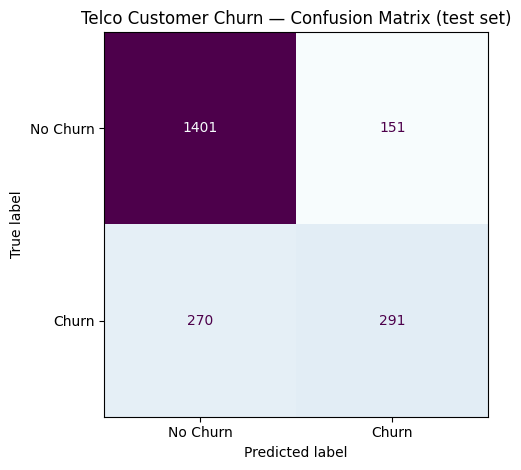

In [7]:
results_telco = run_mlp_pipeline(
    X_telco.values, y_telco,
    dataset_name='Telco Customer Churn',
    class_labels=['No Churn', 'Churn'],
)

---
## 2. Online Shoppers Intention Dataset

In [8]:
df_ecom = pd.read_csv('../data/processed/ecom_clean.csv')
print(f'Shape: {df_ecom.shape}')
print(df_ecom.head())

Shape: (12205, 18)
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0  

In [9]:
X_ecom = df_ecom.drop(columns=['Revenue'])
y_ecom = df_ecom['Revenue'].values

X_ecom = encode_features(X_ecom)

print(f'Features: {X_ecom.shape}  |  Target distribution: {dict(pd.Series(y_ecom).value_counts())}')

Features: (12205, 26)  |  Target distribution: {0: np.int64(10297), 1: np.int64(1908)}



  Online Shoppers Intention
Class distribution:
0    10297
1     1908
Name: count, dtype: int64

Train size: 8543  |  Test size: 3662



Nested CV ROC-AUC scores: [0.9161 0.9208 0.9024 0.9001 0.909 ]
Mean: 0.9097  (+/- 0.0079)



Best hyperparameters selected by inner CV:
  mlp__alpha: 0.01
  mlp__hidden_layer_sizes: (128, 64)

Test set ROC-AUC: 0.9159

Classification report (test set):
              precision    recall  f1-score   support

 No Purchase       0.92      0.96      0.94      3090
    Purchase       0.71      0.57      0.63       572

    accuracy                           0.90      3662
   macro avg       0.82      0.76      0.78      3662
weighted avg       0.89      0.90      0.89      3662



<Figure size 600x500 with 0 Axes>

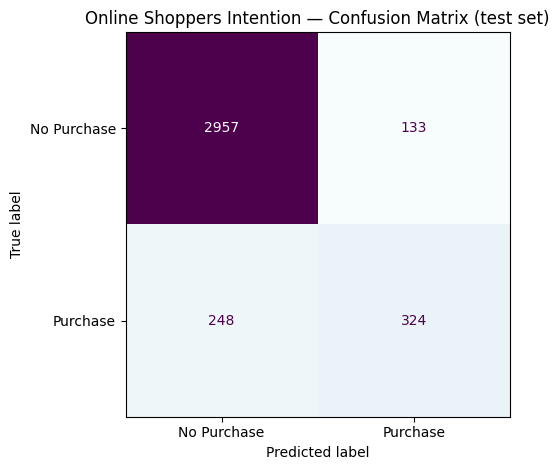

In [10]:
results_ecom = run_mlp_pipeline(
    X_ecom.values, y_ecom,
    dataset_name='Online Shoppers Intention',
    class_labels=['No Purchase', 'Purchase'],
)

---
## 3. Bank Marketing Dataset

In [11]:
df_bank = pd.read_csv('../data/processed/bank_clean.csv')
df_bank = sort_bank_temporally(df_bank)  # chronological order for temporal split
print(f'Shape: {df_bank.shape}')
print(df_bank.head())

Shape: (41176, 21)
   age         job   marital            education default housing loan  \
0   75     retired  divorced             basic.9y      no      no   no   
1   53  technician   married  professional.course      no     yes   no   
2   48  unemployed   married    university.degree      no      no  yes   
3   62  technician   married    university.degree      no     yes   no   
4   29      admin.    single          high.school      no     yes  yes   

     contact month day_of_week  ...  campaign  pdays  previous  poutcome  \
0   cellular   mar         mon  ...         1    6.0         0   failure   
1  telephone   mar         mon  ...         5    6.0         2   failure   
2   cellular   mar         mon  ...         1    6.0         1   failure   
3   cellular   mar         mon  ...         1    6.0         1   success   
4   cellular   mar         mon  ...         1    6.0         0   failure   

  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed  y  
0   

In [12]:
X_bank = df_bank.drop(columns=['y'])
y_bank = df_bank['y'].values

X_bank = encode_features(X_bank)

print(f'Features: {X_bank.shape}  |  Target distribution: {dict(pd.Series(y_bank).value_counts())}')

Features: (41176, 46)  |  Target distribution: {0: np.int64(36537), 1: np.int64(4639)}



  Bank Marketing
Class distribution:
0    36537
1     4639
Name: count, dtype: int64

Temporal split at index 32940 (no shuffling).

Train size: 32940  |  Test size: 8236



Nested CV ROC-AUC scores: [0.9262 0.9258 0.9291 0.9521 0.9409]
Mean: 0.9348  (+/- 0.0102)



Best hyperparameters selected by inner CV:
  mlp__alpha: 0.0001
  mlp__hidden_layer_sizes: (128, 64)

Test set ROC-AUC: 0.9053

Classification report (test set):
                 precision    recall  f1-score   support

No Subscription       0.92      0.93      0.93      6861
   Subscription       0.64      0.57      0.60      1375

       accuracy                           0.87      8236
      macro avg       0.78      0.75      0.76      8236
   weighted avg       0.87      0.87      0.87      8236



<Figure size 600x500 with 0 Axes>

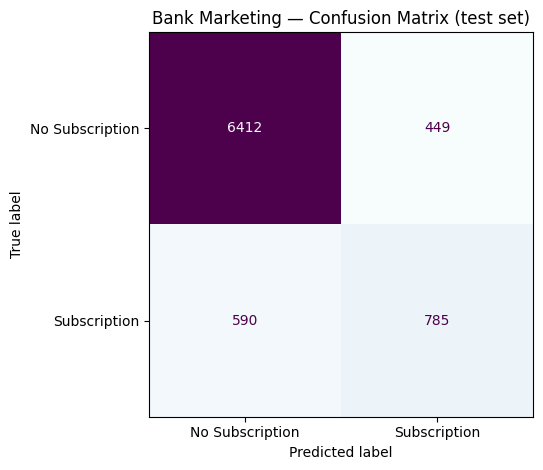

In [13]:
results_bank = run_mlp_pipeline(
    X_bank.values, y_bank,
    dataset_name='Bank Marketing',
    class_labels=['No Subscription', 'Subscription'],
    temporal=True,
)

---
## Summary

In [14]:
summary = pd.DataFrame([results_telco, results_ecom, results_bank])

def _fmt_params(p):
    hl = p['mlp__hidden_layer_sizes']
    return f"{hl}, {p['mlp__alpha']}"

summary_out = pd.DataFrame({
    'Dataset':          summary['dataset'],
    'Architektur, α':   summary['best_params'].map(_fmt_params),
    'CV-AUC':           [f"{m:.4f} ± {s:.4f}" for m, s in zip(summary['mean_cv_score'], summary['cv_score_std'])],
    'Test-AUC':         summary['test_auc'].map('{:.4f}'.format),
    'F1':               summary['test_f1'].map('{:.4f}'.format),
    'Prec.':            summary['test_precision'].map('{:.4f}'.format),
    'Recall':           summary['test_recall'].map('{:.4f}'.format),
})

print('Model Performance Summary (MLP - MLPClassifier):')
print(summary_out.to_string(index=False))


Model Performance Summary (MLP - MLPClassifier):
                  Dataset    Architektur, α          CV-AUC Test-AUC     F1  Prec. Recall
     Telco Customer Churn       (64,), 0.01 0.8293 ± 0.0189   0.8441 0.5803 0.6584 0.5187
Online Shoppers Intention   (128, 64), 0.01 0.9097 ± 0.0079   0.9159 0.6297 0.7090 0.5664
           Bank Marketing (128, 64), 0.0001 0.9348 ± 0.0102   0.9053 0.6018 0.6361 0.5709
